In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# 1. LOAD FILE DARI DRIVE
input_path = '/content/drive/MyDrive/TugasIntegrasiData/year-2026.merged.csv'  # sesuaikan!
df = pd.read_csv(input_path)

print(f"Total data asli: {len(df)}")

Total data asli: 3009760


In [4]:
df_software = df[
    df['paket'].astype(str).str.contains('software|aplikasi', case=False, na=False)
].reset_index(drop=True)

print(f"Hasil filter software & aplikasi: {len(df_software)}")

Hasil filter software & aplikasi: 9755


In [6]:
# 3. SIMPAN HASIL KE DRIVE
output_path = '/content/drive/MyDrive/TugasIntegrasiData/Data_software_filtered.csv'
df_software.to_csv(output_path, index=False)

print(f"✅ Tersimpan ke: {output_path}")

✅ Tersimpan ke: /content/drive/MyDrive/TugasIntegrasiData/Data_software_filtered.csv


In [9]:
df = pd.read_csv('/content/drive/MyDrive/TugasIntegrasiData/Data_software_filtered.csv')

print(f"Jumlah baris: {len(df)}")
print(f"Kolom: {df.columns.tolist()}")
print(f"\nContoh 3 baris pertama:")
df.head(3)

Jumlah baris: 9755
Kolom: ['paket', 'dalamNegeri', 'jenisPengadaan', 'metode', 'lembaga', 'satker', 'lokasi', 'id', 'pagu', 'pemilihanDate', 'sumberDana', 'isUMKM', 'volumePekerjaan', 'uraianPekerjaan', 'spesifikasiPekerjaan', 'ownerType', 'potensiPemborosan', 'tags.isInappropriate', 'tags.inappropriateReason', 'jumlahTagAktif', '_source_part']

Contoh 3 baris pertama:


,paket,dalamNegeri,jenisPengadaan,metode,lembaga,satker,lokasi,id,pagu,pemilihanDate,...,isUMKM,volumePekerjaan,uraianPekerjaan,spesifikasiPekerjaan,ownerType,potensiPemborosan,tags.isInappropriate,tags.inappropriateReason,jumlahTagAktif,_source_part
0,Helpdesk Aplikasi Manajemen Pemerintahan II,True,Jasa Konsultansi,Pengadaan Langsung,Kota Tangerang,DINAS KOMUNIKASI DAN INFORMATIKA,"Banten, Tangerang (Kota)",62568701,83649600.0,December 2025,...,True,12 OB,menjawab keluhan pegawai Pemerintah Kota Tange...,"IT Support / Helpdesk / Operator Komputer, Hel...",kabkota,0.0,low,NaN,0,1
1,IT Support Aplikasi Layanan Publik I,True,Jasa Konsultansi,Pengadaan Langsung,Kota Tangerang,DINAS KOMUNIKASI DAN INFORMATIKA,"Banten, Tangerang (Kota)",62569143,83649600.0,December 2025,...,True,12 OB,Melakukan pendampingan implementasi aplikasi e...,"IT Support / Helpdesk / Operator Komputer, IT ...",kabkota,0.0,low,NaN,0,1
2,IT Support Aplikasi Manajemen Pemerintahan II,True,Jasa Konsultansi,Pengadaan Langsung,Kota Tangerang,DINAS KOMUNIKASI DAN INFORMATIKA,"Banten, Tangerang (Kota)",62569831,83649600.0,December 2025,...,True,12 OB,Mendeteksi dan melacak bug (debugging) - Melak...,"IT Support / Helpdesk / Operator Komputer, IT ...",kabkota,0.0,low,NaN,0,1


In [18]:
import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [19]:
# Ambil kolom nama paket
df['nama_paket'] = df['paket'].astype(str)

# Preprocessing sederhana
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # menghapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # menghapus spasi berlebih
    return text

df['nama_clean'] = df['nama_paket'].apply(clean_text)
df[['nama_paket', 'nama_clean']].head()

,nama_paket,nama_clean
0,Helpdesk Aplikasi Manajemen Pemerintahan II,helpdesk aplikasi manajemen pemerintahan ii
1,IT Support Aplikasi Layanan Publik I,it support aplikasi layanan publik i
2,IT Support Aplikasi Manajemen Pemerintahan II,it support aplikasi manajemen pemerintahan ii
3,APLIKASI LISENSI PREMIUM KEG PENGELOLAAN LAYAN...,aplikasi lisensi premium keg pengelolaan layan...
4,Desain Aplikasi Layanan Publik Tahap 1,desain aplikasi layanan publik tahap 1


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['nama_clean'])

# Hitung similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [21]:
pairs = []

threshold = 0.8

for i in range(len(df)):
    for j in range(i+1, len(df)):
        sim_score = cosine_sim[i, j]

        if sim_score > threshold:
            pairs.append({
                'idx1': i,
                'idx2': j,
                'paket1': df.loc[i, 'nama_paket'],
                'paket2': df.loc[j, 'nama_paket'],
                'similarity': sim_score
            })

pairs_df = pd.DataFrame(pairs)

print(f"Jumlah pasangan mirip (>0.8): {len(pairs_df)}")
pairs_df.head()

Jumlah pasangan mirip (>0.8): 848933


,idx1,idx2,paket1,paket2,similarity
0,0,2295,Helpdesk Aplikasi Manajemen Pemerintahan II,Helpdesk Aplikasi Manajemen Pemerintahan I,0.877101
1,1,2324,IT Support Aplikasi Layanan Publik I,IT Support Aplikasi Layanan Publik II,0.893427
2,2,2326,IT Support Aplikasi Manajemen Pemerintahan II,IT Support Aplikasi Manajemen Pemerintahan I,0.897695
3,4,2534,Desain Aplikasi Layanan Publik Tahap 1,Pengembangan Aplikasi Layanan Publik I Tahap 1,0.805970
4,4,2535,Desain Aplikasi Layanan Publik Tahap 1,Pengembangan Aplikasi Layanan Publik V Tahap 1,0.805970


In [22]:
sample_df = pairs_df.sample(
    n=min(50, len(pairs_df)),
    random_state=42
).reset_index(drop=True)

sample_df

,idx1,idx2,paket1,paket2,similarity
0,5151,7065,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000
1,2538,9116,Pengadaan software pendukung perwajahan publik...,Pengadaan software pendukung perwajahan publik...,1.000000
2,4825,7128,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.000000
3,2917,7334,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000
4,2830,4431,Langganan Aplikasi,Langganan Aplikasi-aplikasi,0.956393
5,3178,7600,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi Sistem Informasi,1.000000
6,1882,7549,Belanja Sewa Aset Tidak Berwujud-Software,Belanja Sewa Aset Tidak Berwujud-Software,1.000000
7,3535,4976,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.000000
8,2745,6077,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000
9,5120,8320,Belanja Modal Aset Tidak Berwujud-Software,Belanja Modal Aset Tidak Berwujud-Software,1.000000


In [23]:
# pastikan kolom label ada
sample_df['label'] = 1

# kalau mau spesifik hanya 50 baris pertama
sample_df.loc[:49, 'label'] = 1
sample_df

,idx1,idx2,paket1,paket2,similarity,label
0,5151,7065,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000,1
1,2538,9116,Pengadaan software pendukung perwajahan publik...,Pengadaan software pendukung perwajahan publik...,1.000000,1
2,4825,7128,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.000000,1
3,2917,7334,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000,1
4,2830,4431,Langganan Aplikasi,Langganan Aplikasi-aplikasi,0.956393,1
5,3178,7600,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi Sistem Informasi,1.000000,1
6,1882,7549,Belanja Sewa Aset Tidak Berwujud-Software,Belanja Sewa Aset Tidak Berwujud-Software,1.000000,1
7,3535,4976,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.000000,1
8,2745,6077,Belanja Pemeliharaan Aset Tidak Berwujud-Software,Belanja Pemeliharaan Aset Tidak Berwujud-Software,1.000000,1
9,5120,8320,Belanja Modal Aset Tidak Berwujud-Software,Belanja Modal Aset Tidak Berwujud-Software,1.000000,1


Klasifikasi dengan Pembobotan (Weighted Scoring)

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [33]:
df['nama_clean'] = df['paket'].apply(clean_text)
df['uraian_clean'] = df['uraianPekerjaan'].apply(clean_text)
df['metode_clean'] = df['metode'].apply(clean_text)

In [34]:
# TF-IDF untuk mengubah nama paket menjadi vektor numerik,
# lalu dihitung cosine similarity untuk melihat kemiripan antar paket

tfidf_nama = TfidfVectorizer()
mat_nama = tfidf_nama.fit_transform(df['nama_clean'])
cosine_nama = cosine_similarity(mat_nama)

In [35]:
# TF-IDF untuk mengubah uraian menjadi vektor numerik,
# lalu dihitung cosine similarity untuk melihat kemiripan antar uraian
tfidf_uraian = TfidfVectorizer()
mat_uraian = tfidf_uraian.fit_transform(df['uraian_clean'])
cosine_uraian = cosine_similarity(mat_uraian)

In [38]:
# Menghitung kesamaan metode pengadaan menggunakan exact match:
# 1 jika metode sama, 0 jika metode berbeda
sim_metode = 1 if df.loc[i, 'metode_clean'] == df.loc[j, 'metode_clean'] else 0

In [39]:
# Menghitung skor kemiripan gabungan antar dua paket
# berdasarkan:
# - similarity nama paket (TF-IDF + cosine similarity)
# - similarity uraian pekerjaan (TF-IDF + cosine similarity)
# - kesamaan metode pengadaan (exact match)
def weighted_score(i, j):

    # similarity nama paket
    sim_nama = cosine_nama[i, j]

    # similarity uraian
    sim_uraian = cosine_uraian[i, j]

    # metode exact match
    sim_metode = 1 if df.loc[i, 'metode'] == df.loc[j, 'metode'] else 0

    # bobot (3 kolom saja)
    w_nama = 0.5
    w_uraian = 0.3
    w_metode = 0.2

    score = (
        w_nama * sim_nama +
        w_uraian * sim_uraian +
        w_metode * sim_metode
    )

    return score

In [46]:
pairs_df['paket1'] = pairs_df['idx1'].apply(lambda i: df.loc[i, 'nama_paket'])
pairs_df['paket2'] = pairs_df['idx2'].apply(lambda i: df.loc[i, 'nama_paket'])

In [47]:
pairs_df['sim_nama'] = pairs_df.apply(
    lambda row: cosine_nama[row['idx1'], row['idx2']],
    axis=1
)

pairs_df['sim_uraian'] = pairs_df.apply(
    lambda row: cosine_uraian[row['idx1'], row['idx2']],
    axis=1
)

pairs_df['sim_metode'] = pairs_df.apply(
    lambda row: 1 if df.loc[row['idx1'], 'metode_clean'] == df.loc[row['idx2'], 'metode_clean'] else 0,
    axis=1
)

In [48]:
pairs_df['weighted_score'] = (
    0.5 * pairs_df['sim_nama'] +
    0.3 * pairs_df['sim_uraian'] +
    0.2 * pairs_df['sim_metode']
)

pairs_df['label_pred'] = pairs_df['weighted_score'].apply(
    lambda x: 1 if x > 0.8 else 0
)

In [49]:
result_df = pairs_df[[
    'idx1', 'idx2', 'paket1', 'paket2',
    'sim_nama',
    'sim_uraian',
    'sim_metode',
    'weighted_score',
    'label_pred'
]]

In [53]:
result_df.head(3)

,idx1,idx2,paket1,paket2,sim_nama,sim_uraian,sim_metode,weighted_score,label_pred
0,0,2295,Helpdesk Aplikasi Manajemen Pemerintahan II,Helpdesk Aplikasi Manajemen Pemerintahan I,0.877101,0.691265,1,0.845930,1
1,1,2324,IT Support Aplikasi Layanan Publik I,IT Support Aplikasi Layanan Publik II,0.893427,1.000000,1,0.946714,1
2,2,2326,IT Support Aplikasi Manajemen Pemerintahan II,IT Support Aplikasi Manajemen Pemerintahan I,0.897695,0.136933,1,0.689927,0


In [55]:
# Hasilnya disimpan
len(result_df)
result_df.to_excel('/content/drive/MyDrive/TugasIntegrasiData/Hasil_pairs_pbj.xlsx', index=False)

In [ ]:
Analisis & Visualisasi

In [58]:
result_df['anggaran1'] = result_df['idx1'].apply(lambda i: df.loc[i, 'pagu'])
result_df['anggaran2'] = result_df['idx2'].apply(lambda i: df.loc[i, 'pagu'])

result_df['metode1'] = result_df['idx1'].apply(lambda i: df.loc[i, 'metode_clean'])
result_df['metode2'] = result_df['idx2'].apply(lambda i: df.loc[i, 'metode_clean'])

/tmp/ipykernel_4226/3048774161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['anggaran1'] = result_df['idx1'].apply(lambda i: df.loc[i, 'pagu'])
/tmp/ipykernel_4226/3048774161.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['anggaran2'] = result_df['idx2'].apply(lambda i: df.loc[i, 'pagu'])
/tmp/ipykernel_4226/3048774161.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See 

In [59]:
# Hitung Selisih Anggaran
result_df['selisih_persen'] = abs(
    result_df['anggaran1'] - result_df['anggaran2']
) / (
    (result_df['anggaran1'] + result_df['anggaran2']) / 2
)


/tmp/ipykernel_4226/1453786052.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['selisih_persen'] = abs(


In [81]:
# Filter anomali anggaran
anomali_df = result_df[
    (result_df['sim_nama'] > 0.8) &           # mirip
    (result_df['sim_uraian'] > 0.8) &
    (result_df['selisih_persen'] > 0.5) &     # beda > 50%
    (result_df['metode1'] != result_df['metode2'])  # metode beda
]

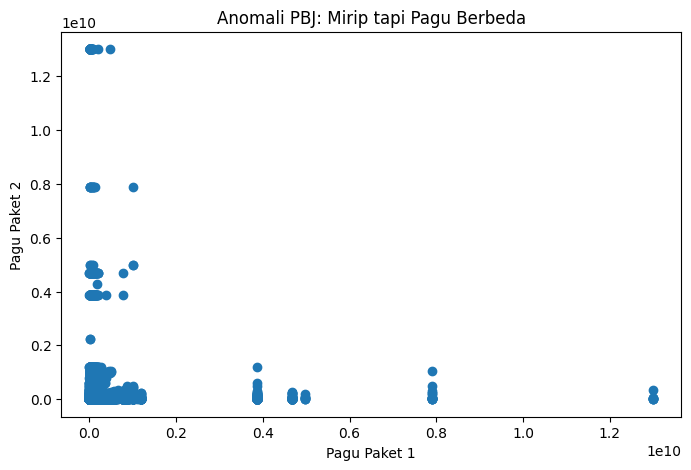

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    anomali_df['anggaran1'],
    anomali_df['anggaran2']
)

plt.xlabel("Pagu Paket 1")
plt.ylabel("Pagu Paket 2")
plt.title("Anomali PBJ: Mirip tapi Pagu Berbeda")

plt.show()

In [86]:
anomali_sorted = anomali_df[[
    'paket1', 'paket2',
    'anggaran1', 'anggaran2',
    'selisih_persen'
]].sort_values(
    'selisih_persen', ascending=False
)

In [87]:
file_path = '/content/drive/MyDrive/TugasIntegrasiData/data_anomali_anggaran.xlsx'

anomali_sorted.to_excel(file_path, index=False)

In [88]:
# anomali metode
anomali_metode = result_df[
    (result_df['sim_nama'] > 0.8) &
    (result_df['sim_uraian'] > 0.8) &
    (result_df['metode1'] != result_df['metode2'])
].copy()

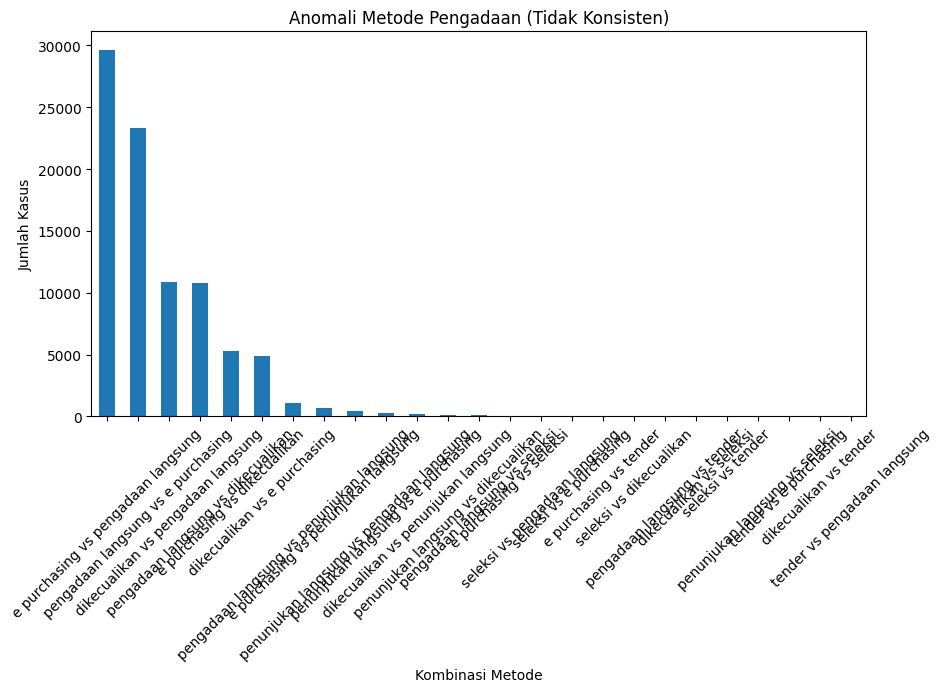

In [90]:
anomali_metode['metode_pair'] = (
    anomali_metode['metode1'].astype(str) + " vs " +
    anomali_metode['metode2'].astype(str)
)

plt.figure(figsize=(10,5))

anomali_metode['metode_pair'].value_counts().plot(kind='bar')

plt.title("Anomali Metode Pengadaan (Tidak Konsisten)")
plt.xlabel("Kombinasi Metode")
plt.ylabel("Jumlah Kasus")

plt.xticks(rotation=45)
plt.show()

In [92]:
anomali_metode[[
    'paket1', 'paket2',
    'metode1', 'metode2'
]]


,paket1,paket2,metode1,metode2
499,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,dikecualikan
500,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,e purchasing
505,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,e purchasing
506,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,e purchasing
507,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,dikecualikan
...,...,...,...,...
848898,Pengadaan software pendukung perwajahan publik...,Pengadaan software pendukung perwajahan publik...,pengadaan langsung,dikecualikan
848921,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,penunjukan langsung
848925,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,penunjukan langsung
848928,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,pengadaan langsung,penunjukan langsung


In [94]:
file_path = '/content/drive/MyDrive/TugasIntegrasiData/data_anomali_metode.xlsx'

anomali_metode.to_excel(file_path, index=False)

In [95]:
# anomali metode dan anggaran
anomali_final = result_df[
    (result_df['sim_nama'] > 0.8) &
    (result_df['sim_uraian'] > 0.8) &
    (result_df['selisih_persen'] > 0.5) &
    (result_df['metode1'] != result_df['metode2'])
].copy()

In [102]:
anomali_final['lokasi1'] = anomali_final['idx1'].apply(lambda i: df.loc[i, 'lokasi'])
anomali_final['lokasi2'] = anomali_final['idx2'].apply(lambda i: df.loc[i, 'lokasi'])

anomali_final['satker1'] = anomali_final['idx1'].apply(lambda i: df.loc[i, 'satker'])
anomali_final['satker2'] = anomali_final['idx2'].apply(lambda i: df.loc[i, 'satker'])

anomali_final[[
    'paket1', 'paket2',
    'sim_nama', 'sim_uraian',
    'anggaran1', 'anggaran2',
    'selisih_persen',
    'metode1', 'metode2', 'satker1','satker2','lokasi1','lokasi2'
]]

,paket1,paket2,sim_nama,sim_uraian,anggaran1,anggaran2,selisih_persen,metode1,metode2,satker1,satker2,lokasi1,lokasi2
499,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,0.93316,25000000.0,12000000.0,0.702703,pengadaan langsung,dikecualikan,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN,Puskesmas Paal X,"Jawa Tengah, Kendal (Kab.)","Jambi, Jambi (Kota)"
500,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,25000000.0,14000000.0,0.564103,pengadaan langsung,e purchasing,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN,Inspektorat,"Jawa Tengah, Kendal (Kab.)","Jawa Timur, Lamongan (Kab.)"
506,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,0.93316,25000000.0,106000000.0,1.236641,pengadaan langsung,e purchasing,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN,DINAS KOMUNIKASI DAN INFORMATIKA,"Jawa Tengah, Kendal (Kab.)","Bali, Tabanan (Kab.)"
507,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,0.93316,25000000.0,853600.0,1.867933,pengadaan langsung,dikecualikan,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN,Puskesmas Sidareja,"Jawa Tengah, Kendal (Kab.)","Jawa Tengah, Cilacap (Kab.)"
508,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,25000000.0,5000000.0,1.333333,pengadaan langsung,e purchasing,DINAS PERUMAHAN RAKYAT DAN KAWASAN PERMUKIMAN,Inspektorat,"Jawa Tengah, Kendal (Kab.)","Jawa Timur, Lamongan (Kab.)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
848853,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,12000000.0,2700000.0,1.265306,pengadaan langsung,penunjukan langsung,Dinas Pendidikan,Puskesmas Simpang Gaung,"Jawa Barat, Sukabumi (Kab.)","Riau, Indragiri Hilir (Kab.)"
848921,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,180390500.0,2700000.0,1.941013,pengadaan langsung,penunjukan langsung,"Dinas Koperasi, Perindustrian dan Perdagangan",Puskesmas Simpang Gaung,"Jawa Timur, Lamongan (Kab.)","Riau, Indragiri Hilir (Kab.)"
848925,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,14400000.0,2700000.0,1.368421,pengadaan langsung,penunjukan langsung,Puskesmas Enok,Puskesmas Simpang Gaung,"Riau, Indragiri Hilir (Kab.)","Riau, Indragiri Hilir (Kab.)"
848928,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,1.0,1.00000,13200000.0,2700000.0,1.320755,pengadaan langsung,penunjukan langsung,Puskesmas Tembilahan Hulu,Puskesmas Simpang Gaung,"Riau, Indragiri Hilir (Kab.)","Riau, Indragiri Hilir (Kab.)"


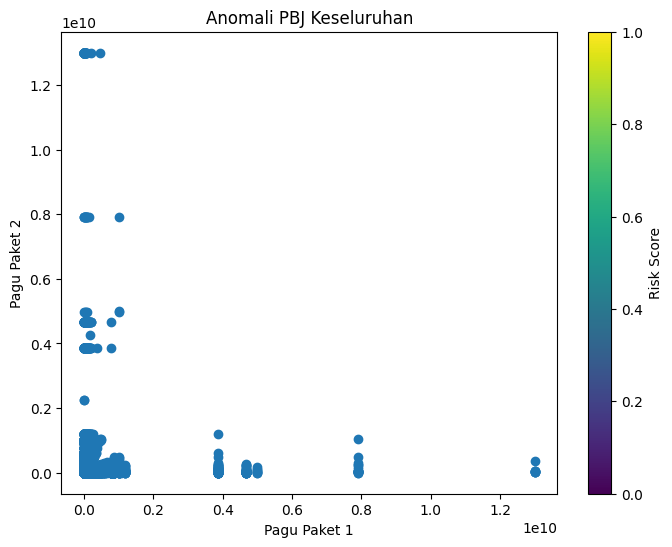

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    anomali_final['anggaran1'],
    anomali_final['anggaran2']

)

plt.colorbar(label='Risk Score')

plt.xlabel("Pagu Paket 1")
plt.ylabel("Pagu Paket 2")
plt.title("Anomali PBJ Keseluruhan")

plt.show()

In [104]:
file_path = '/content/drive/MyDrive/TugasIntegrasiData/data_anomali_final.xlsx'

anomali_final[[
    'paket1', 'paket2',
    'sim_nama', 'sim_uraian',
    'anggaran1', 'anggaran2',
    'selisih_persen',
    'metode1', 'metode2', 'satker1','satker2','lokasi1','lokasi2'
]].to_excel(file_path, index=False)

In [106]:
# anomali barang dengan spesifikasi sama, harga beda jauh, lokasi & satker sama
anomali_konteks = anomali_final[  # bisa juga dari result_df langsung
    (anomali_final['sim_nama'] > 0.8) &
    (anomali_final['sim_uraian'] > 0.8) &
    (anomali_final['selisih_persen'] > 0.5) &
    (anomali_final['lokasi1'] == anomali_final['lokasi2']) &
    (anomali_final['satker1'] == anomali_final['satker2'])
].copy()

In [110]:
anomali_konteks[[
    'paket1', 'paket2',
    'satker1',
    'lokasi1',
    'anggaran1', 'anggaran2',
    'selisih_persen',
    'sim_nama', 'sim_uraian'
]].sort_values('selisih_persen', ascending=False)

,paket1,paket2,satker1,lokasi1,anggaran1,anggaran2,selisih_persen,sim_nama,sim_uraian
673195,Belanja Modal Aset Tidak Berwujud-Software,Belanja Modal Aset Tidak Berwujud-Software,Dinas Komunikasi dan Informatika,"Papua Tengah, Mimika (Kab.)",2000000.0,7.900000e+09,1.998988,1.000000,1.000000
340926,Pengadaan Alat/Bahan untuk Kegiatan Kantor-Ben...,Pengadaan Pelatihan AI sub kegiatan Koordinasi...,"Dinas Komunikasi, Informatika dan Digital","Jawa Tengah, Semarang (Kota)",500000.0,2.000000e+08,1.990025,0.840374,0.843491
649746,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Dinas Pemberdayaan Masyarakat dan Desa,"Jawa Barat, Sukabumi (Kab.)",3500000.0,4.140000e+08,1.966467,1.000000,1.000000
7550,Pengadaan Makanan dan Minuman Rapat sub kegiat...,Pengadaan Alat/Bahan untuk Kegiatan Kantor-Ben...,"Dinas Komunikasi, Informatika dan Digital","Jawa Tengah, Semarang (Kota)",50100000.0,5.000000e+05,1.960474,0.830773,0.830698
630564,Belanja Sewa Aset Tidak Berwujud-Software (BOS...,Belanja Modal Aset Tidak Berwujud-Software (BO...,Dinas Pendidikan dan Kebudayaan,"Kalimantan Timur, Kutai Kartanegara (Kab.)",338094665.0,4.625235e+06,1.946017,0.947230,0.929521
...,...,...,...,...,...,...,...,...,...
394391,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Belanja Jasa Konversi Aplikasi/Sistem Informasi,Dinas Komunikasi dan Informatika Daerah,"Sulawesi Utara, Sangihe Talaud (Kab.)",25000000.0,1.300000e+07,0.631579,1.000000,1.000000
802653,"BELANJA PENYEDIAAN JASA APLIKASI, KOMUNIKASI, ...","BELANJA PENYEDIAAN JASA APLIKASI, KOMUNIKASI, ...",UPT PUSKESMAS NEGLASARI,"Banten, Tangerang (Kota)",21711000.0,1.150000e+07,0.614917,0.803016,1.000000
422568,Latsat Bin Proglatsi UML Aplikasi Proglatsi No...,Latsat Bin Proglatsi UML Aplikasi Proglatsi No...,Makodam IX Udy TNI AD,"Bali, Buleleng (Kab.)",111960000.0,2.070000e+08,0.595937,0.878841,0.865203
483244,Pemeliharaan aplikasi/ sistem SKPD berbasis mo...,Pemeliharaan aplikasi/ sistem SKPD berbasis mo...,DINAS KOMUNIKASI DAN INFORMATIKA,"DI Yogyakarta, Sleman (Kab.)",60000000.0,3.500000e+07,0.526316,0.855038,0.889397


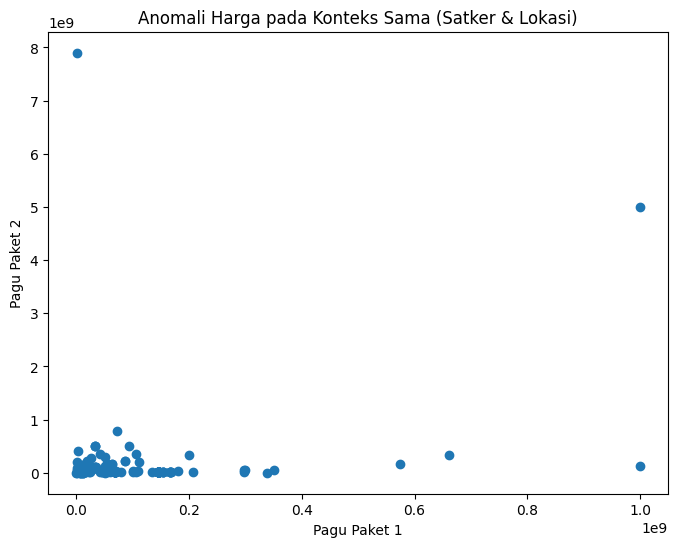

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    anomali_konteks['anggaran1'],
    anomali_konteks['anggaran2']
)

plt.xlabel("Pagu Paket 1")
plt.ylabel("Pagu Paket 2")
plt.title("Anomali Harga pada Konteks Sama (Satker & Lokasi)")

plt.show()

In [112]:
anomali_konteks_sorted = anomali_konteks[[
    'paket1', 'paket2',
    'satker1',
    'lokasi1',
    'anggaran1', 'anggaran2',
    'selisih_persen',
    'sim_nama', 'sim_uraian'
]].sort_values('selisih_persen', ascending=False)

In [113]:
file_path = '/content/drive/MyDrive/TugasIntegrasiData/data_anomali_konteks.xlsx'

anomali_konteks_sorted.to_excel(file_path, index=False)